# Notebook 04 — Greeks & Sensitivity Analysis

**Option Pricing Horizon** | Task 4 of 5

---

## Learning Objectives
1. Compare European and Asian option Greeks side by side
2. Perform full sensitivity sweeps: σ, K, r, N, T
3. Visualise how the price difference (European − Asian) changes with parameters
4. Understand why Asian options are preferred hedging instruments
5. Demonstrate Delta estimation via CRN finite-differences for the Asian MC pricer

---

## 1. Comparison of Analytical Greeks: European vs Geometric Asian

The geometric Asian closed-form allows us to compute Greeks analytically via
differentiation of the Kemna-Vorst formula — they take the same form as BS
Greeks but with adjusted parameters $(F_G, \sigma_G)$.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

from option_pricing_horizon.common.market_params import MarketParams
from option_pricing_horizon.european.black_scholes import bs_call_price, bs_put_price
from option_pricing_horizon.european.greeks import (
    bs_delta, bs_gamma, bs_theta, bs_vega, bs_rho, bs_all_greeks
)
from option_pricing_horizon.asian.geometric import (
    geometric_asian_call, geometric_asian_put, geo_asian_adjusted_params
)
from option_pricing_horizon.asian.monte_carlo import arithmetic_asian_mc
from option_pricing_horizon.asian.greeks import asian_delta, asian_vega, asian_rho
from option_pricing_horizon.asian.convergence import monitoring_freq_study

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})

mp = MarketParams.baseline()
print(mp)

MarketParams(S0=100.0, K=100.0, r=0.03, sigma=0.2, T=1.0, N=252, q=0.0)


## 2. Greeks of Geometric Asian Option (Closed-Form via Adjusted BS)

The geometric Asian option with parameters $(F_G, \sigma_G)$ has exactly the
same Greek formulas as the European BS option — just substitute:
- $S_0 \to F_G \cdot e^{-rT}$ (or equivalently use $F_G$ as a "forward")
- $\sigma \to \sigma_G / \sqrt{T}$ (annualised adjusted vol)

In [2]:
from option_pricing_horizon.common.math_utils import norm_cdf, norm_pdf

def geo_asian_greeks(S, K, r, sigma, T, N, option_type='call'):
    """Compute Greeks of geometric Asian option via adjusted BS formula."""
    p  = geo_asian_adjusted_params(S, K, r, sigma, T, N)
    FG = p['F_G']
    sG = p['sigma_G']
    disc = np.exp(-r * T)
    if sG < 1e-14:
        return {'delta': 0.0, 'gamma': 0.0, 'theta': 0.0, 'vega': 0.0}
    d1 = (np.log(FG / K) + 0.5 * sG**2) / sG
    d2 = d1 - sG
    # delta wrt S: dC/dS = disc * dFG/dS * Phi(d1)
    # dFG/dS = FG/S
    sgn = 1.0 if option_type == 'call' else -1.0
    N1 = norm_cdf(sgn * d1)
    N2 = norm_cdf(sgn * d2)
    delta = disc * (FG / S) * N1
    if option_type == 'put':
        delta = -disc * (FG / S) * norm_cdf(-d1)
    # Vega wrt sigma: numerical (central diff, per 1%)
    h = 0.001
    price_up   = geometric_asian_call(S, K, r, sigma + h, T, N) if option_type == 'call' else geometric_asian_put(S, K, r, sigma + h, T, N)
    price_down = geometric_asian_call(S, K, r, sigma - h, T, N) if option_type == 'call' else geometric_asian_put(S, K, r, sigma - h, T, N)
    vega = (price_up - price_down) / (2 * h) / 100.0
    return {'delta': float(delta), 'vega': float(vega)}


# Side-by-side comparison at baseline
eu_g  = bs_all_greeks(mp.S0, mp.K, mp.r, mp.sigma, mp.T, 'call')
geo_g = geo_asian_greeks(mp.S0, mp.K, mp.r, mp.sigma, mp.T, mp.N, 'call')

compare_df = pd.DataFrame({
    'European (BS)':       eu_g,
    'Geo Asian (adjusted)': geo_g,
}).rename(index=str.title)
compare_df.index.name = 'Greek'
print("Greeks Comparison at Baseline: European Call vs Geometric Asian Call")
print(compare_df.to_string(float_format='{:.6f}'.format))
print("\nKey insight: Asian option has lower Delta and Vega — it is less sensitive")
print("to spot and vol moves because the average smooths out extreme outcomes.")

Greeks Comparison at Baseline: European Call vs Geometric Asian Call
       European (BS)  Geo Asian (adjusted)
Greek                                     
Delta       0.598706              0.553029
Gamma       0.019333                   NaN
Theta      -0.014741                   NaN
Vega        0.386668              0.205543
Rho         0.504572                   NaN

Key insight: Asian option has lower Delta and Vega — it is less sensitive
to spot and vol moves because the average smooths out extreme outcomes.


## 3. Delta Comparison: European vs Asian across Spot Prices

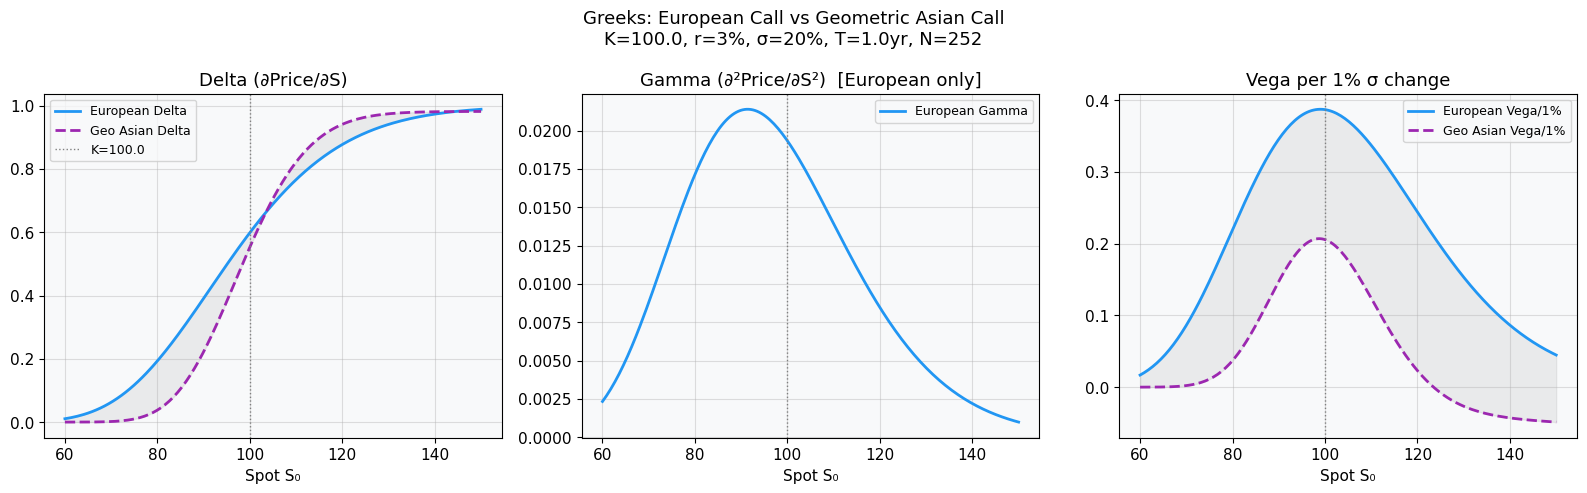

In [3]:
S_range = np.linspace(60, 150, 200)
K, r, sigma, T, N = mp.K, mp.r, mp.sigma, mp.T, mp.N

eu_deltas  = np.array([bs_delta(S, K, r, sigma, T, 'call') for S in S_range])
eu_gammas  = np.array([bs_gamma(S, K, r, sigma, T)          for S in S_range])
eu_vegas   = np.array([bs_vega(S, K, r, sigma, T, per_percent=True) for S in S_range])

geo_deltas = np.array([geo_asian_greeks(S, K, r, sigma, T, N)['delta'] for S in S_range])
geo_vegas  = np.array([geo_asian_greeks(S, K, r, sigma, T, N)['vega']  for S in S_range])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Greeks: European Call vs Geometric Asian Call\n'
             f'K={K}, r={r:.0%}, σ={sigma:.0%}, T={T}yr, N={N}', fontsize=13)

# Delta
axes[0].plot(S_range, eu_deltas,  color='#2196F3', lw=2, label='European Delta')
axes[0].plot(S_range, geo_deltas, color='#9C27B0', lw=2, ls='--', label='Geo Asian Delta')
axes[0].fill_between(S_range, geo_deltas, eu_deltas, alpha=0.12, color='grey')
axes[0].axvline(K, color='grey', lw=1, ls=':', label=f'K={K}')
axes[0].set_xlabel('Spot S₀')
axes[0].set_title('Delta (∂Price/∂S)')
axes[0].legend(fontsize=9)

# Gamma
axes[1].plot(S_range, eu_gammas, color='#2196F3', lw=2, label='European Gamma')
axes[1].axvline(K, color='grey', lw=1, ls=':')
axes[1].set_xlabel('Spot S₀')
axes[1].set_title('Gamma (∂²Price/∂S²)  [European only]')
axes[1].legend(fontsize=9)

# Vega
axes[2].plot(S_range, eu_vegas,  color='#2196F3', lw=2, label='European Vega/1%')
axes[2].plot(S_range, geo_vegas, color='#9C27B0', lw=2, ls='--', label='Geo Asian Vega/1%')
axes[2].fill_between(S_range, geo_vegas, eu_vegas, alpha=0.12, color='grey')
axes[2].axvline(K, color='grey', lw=1, ls=':')
axes[2].set_xlabel('Spot S₀')
axes[2].set_title('Vega per 1% σ change')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 4. Sensitivity Analysis: Price vs σ, K, r, N

We sweep each parameter independently while holding all others at baseline.

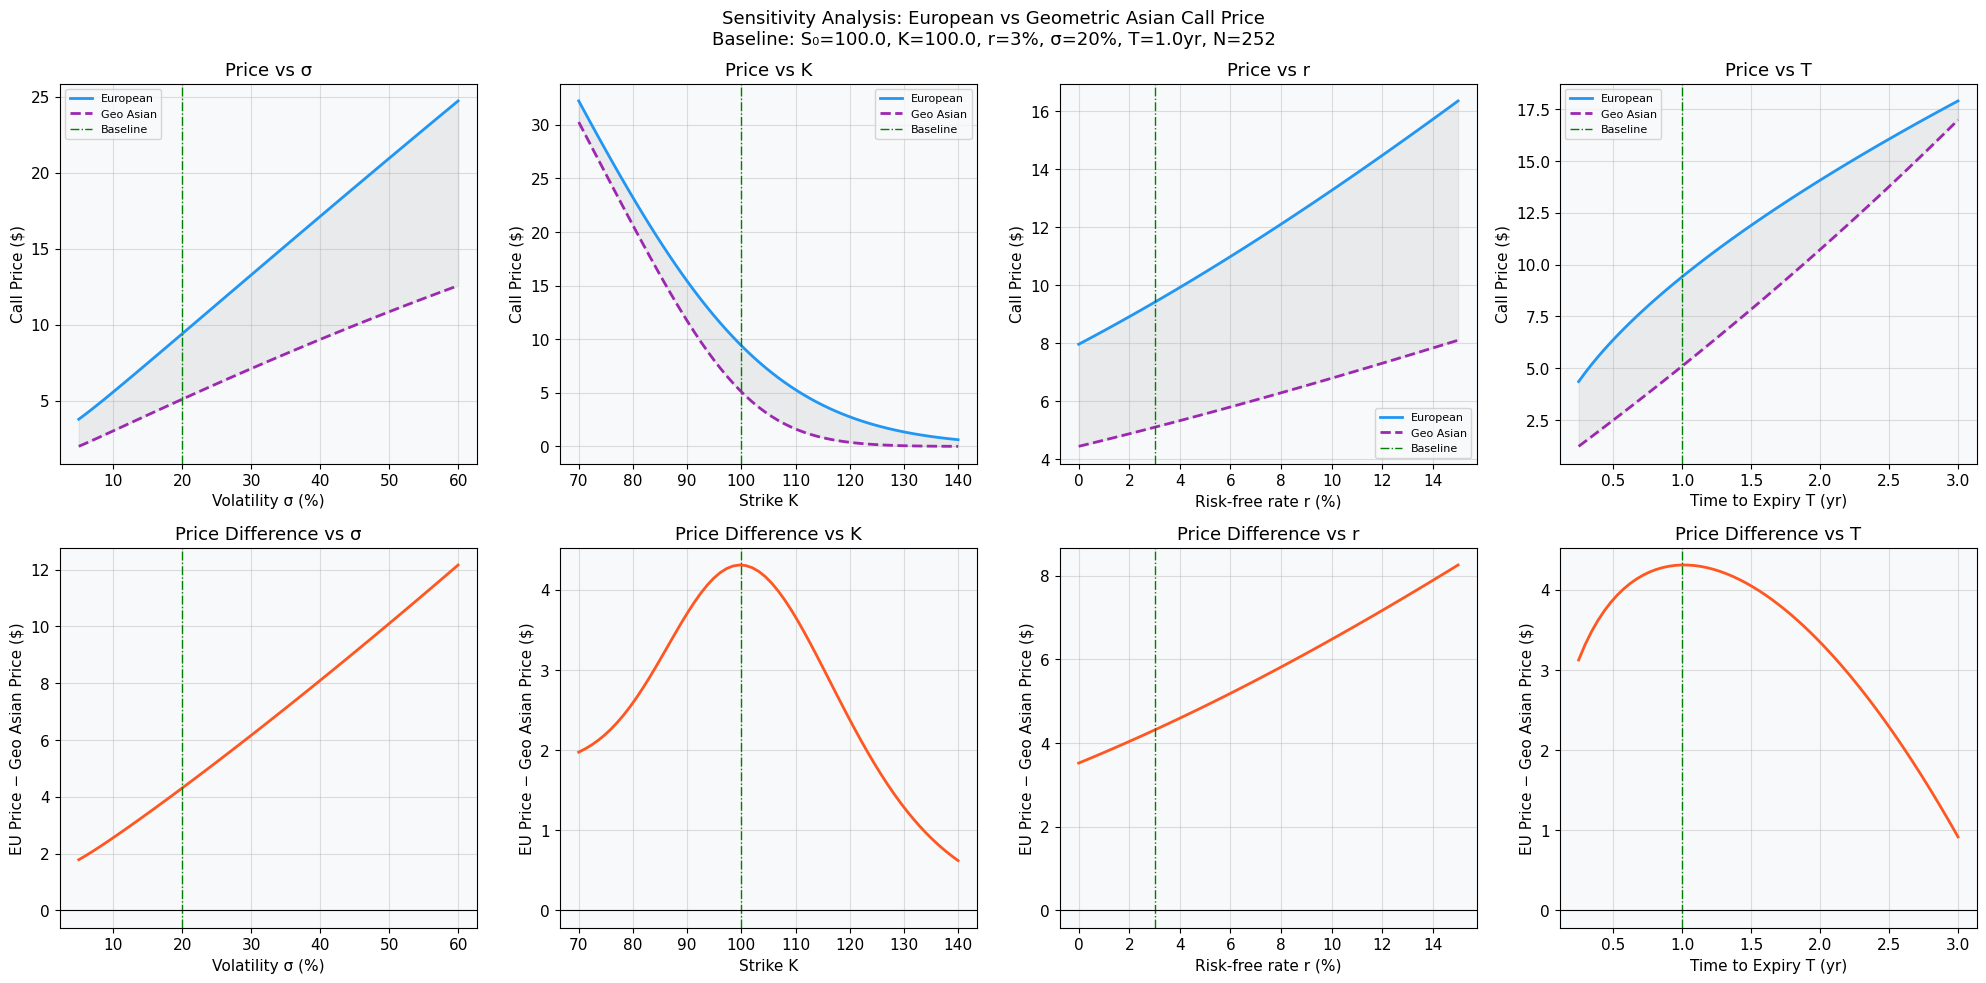

In [4]:
# ── Sensitivity sweep data ────────────────────────────────────────────────
sigma_range = np.linspace(0.05, 0.60, 60)
K_range     = np.linspace(70,  140,  60)
r_range     = np.linspace(0.0,  0.15, 60)
T_range     = np.linspace(0.25,  3.0,  60)
N_range     = np.array([1, 2, 4, 12, 52, 63, 126, 252, 504])

def sweep(param_name, param_range):
    eu_prices, geo_prices, diff = [], [], []
    for val in param_range:
        kw = dict(S=mp.S0, K=mp.K, r=mp.r, sigma=mp.sigma, T=mp.T)
        kw[param_name] = val
        eu = bs_call_price(kw['S'], kw['K'], kw['r'], kw['sigma'], kw['T'])
        N_  = mp.N if param_name != 'N' else int(val)
        if param_name == 'N':
            geo = geometric_asian_call(kw['S'], kw['K'], kw['r'], kw['sigma'], kw['T'], int(val))
        else:
            geo = geometric_asian_call(kw['S'], kw['K'], kw['r'], kw['sigma'], kw['T'], N_)
        eu_prices.append(eu)
        geo_prices.append(geo)
        diff.append(eu - geo)
    return np.array(eu_prices), np.array(geo_prices), np.array(diff)

eu_sig, geo_sig, diff_sig = sweep('sigma', sigma_range)
eu_K,   geo_K,   diff_K   = sweep('K',     K_range)
eu_r,   geo_r,   diff_r   = sweep('r',     r_range)
eu_T,   geo_T,   diff_T   = sweep('T',     T_range)

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Sensitivity Analysis: European vs Geometric Asian Call Price\n'
             f'Baseline: S₀={mp.S0}, K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr, N={mp.N}',
             fontsize=13)

sweeps = [
    (sigma_range * 100, eu_sig, geo_sig, diff_sig, 'Volatility σ (%)',    'σ'),
    (K_range,           eu_K,   geo_K,   diff_K,   'Strike K',            'K'),
    (r_range * 100,     eu_r,   geo_r,   diff_r,   'Risk-free rate r (%)', 'r'),
    (T_range,           eu_T,   geo_T,   diff_T,   'Time to Expiry T (yr)','T'),
]

for col, (x, eu, geo, diff, xlabel, pname) in enumerate(sweeps):
    # Price row
    ax_price = axes[0, col]
    ax_price.plot(x, eu,  color='#2196F3', lw=2, label='European')
    ax_price.plot(x, geo, color='#9C27B0', lw=2, ls='--', label='Geo Asian')
    ax_price.fill_between(x, geo, eu, alpha=0.12, color='grey')
    baseline_val = {'σ': mp.sigma*100, 'K': mp.K, 'r': mp.r*100, 'T': mp.T}[pname]
    ax_price.axvline(baseline_val, color='green', lw=1, ls='-.', label='Baseline')
    ax_price.set_xlabel(xlabel)
    ax_price.set_ylabel('Call Price ($)')
    ax_price.set_title(f'Price vs {pname}')
    ax_price.legend(fontsize=8)

    # Price difference row
    ax_diff = axes[1, col]
    ax_diff.plot(x, diff, color='#FF5722', lw=2)
    ax_diff.axvline(baseline_val, color='green', lw=1, ls='-.')
    ax_diff.axhline(0, color='black', lw=0.8)
    ax_diff.set_xlabel(xlabel)
    ax_diff.set_ylabel('EU Price − Geo Asian Price ($)')
    ax_diff.set_title(f'Price Difference vs {pname}')

plt.tight_layout()
plt.show()

## 5. Monitoring Frequency N Sensitivity

Running monitoring frequency study (MC pricing)...
Done.

     N   Arith Asian     Geo Asian       Vanilla    Arith−Geo
---------------------------------------------------------------
     1  $   9.413403  $   9.413403  $   9.413403  $  0.000000
     2  $   7.360666  $   7.206261  $   9.413403  $  0.154405
     4  $   6.324909  $   6.137644  $   9.413403  $  0.187265
    12  $   5.631624  $   5.435333  $   9.413403  $  0.196292
    52  $   5.363073  $   5.166873  $   9.413403  $  0.196199
    63  $   5.349615  $   5.152832  $   9.413403  $  0.196783
   126  $   5.315937  $   5.119650  $   9.413403  $  0.196286
   252  $   5.300881  $   5.103063  $   9.413403  $  0.197818
   504  $   5.292344  $   5.094771  $   9.413403  $  0.197573


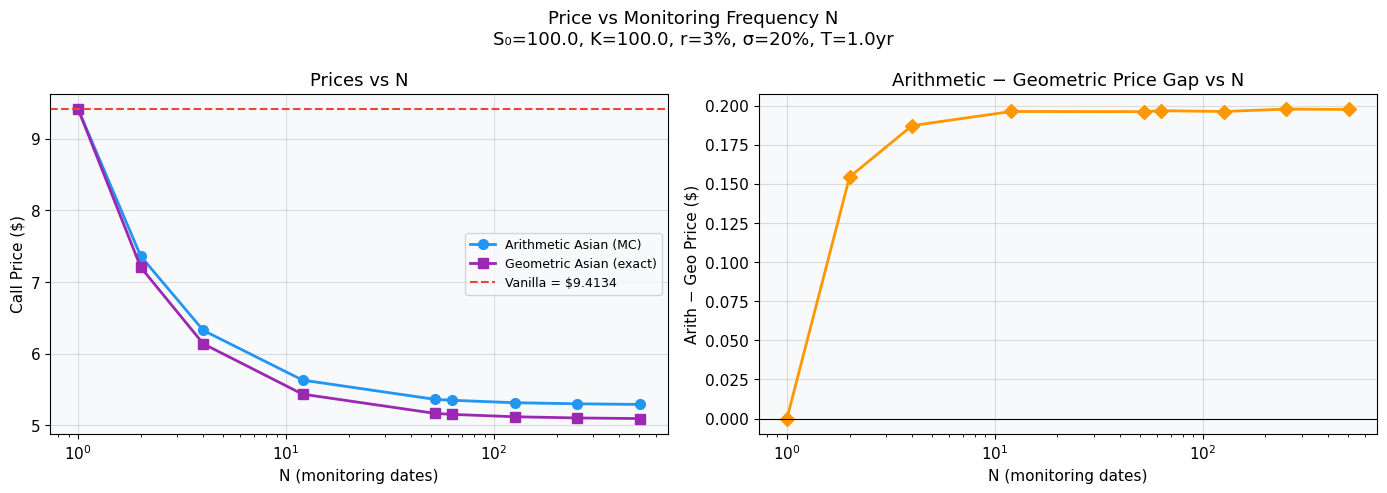


Key insight: as N increases, the gap narrows (arithmetic → geometric for continuous avg)


In [5]:
N_grid = [1, 2, 4, 12, 52, 63, 126, 252, 504]
print("Running monitoring frequency study (MC pricing)...")
freq_results = monitoring_freq_study(
    mp.S0, mp.K, mp.r, mp.sigma, mp.T,
    N_grid=N_grid, n_paths=50_000, seed=42
)
print("Done.\n")

N_arr     = np.array([r['N']            for r in freq_results])
arith_arr = np.array([r['arith_price']  for r in freq_results])
geo_arr   = np.array([r['geo_price']    for r in freq_results])
van_arr   = np.array([r['vanilla_price'] for r in freq_results])
arith_se  = np.array([r['arith_se']     for r in freq_results])

print(f"{'N':>6}  {'Arith Asian':>12}  {'Geo Asian':>12}  {'Vanilla':>12}  {'Arith−Geo':>11}")
print("-" * 63)
for r in freq_results:
    print(f"{r['N']:>6}  ${r['arith_price']:>11.6f}  ${r['geo_price']:>11.6f}  "
          f"${r['vanilla_price']:>11.6f}  ${r['arith_price']-r['geo_price']:>10.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Price vs Monitoring Frequency N\n'
             f'S₀={mp.S0}, K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr', fontsize=13)

axes[0].semilogx(N_arr, arith_arr, 'o-', color='#2196F3', lw=2, ms=7,
                 label='Arithmetic Asian (MC)')
axes[0].fill_between(N_arr, arith_arr - 1.96*arith_se, arith_arr + 1.96*arith_se,
                     alpha=0.2, color='#2196F3')
axes[0].semilogx(N_arr, geo_arr,  's-', color='#9C27B0', lw=2, ms=7, label='Geometric Asian (exact)')
axes[0].axhline(van_arr[0], color='#F44336', lw=1.5, ls='--', label=f'Vanilla = ${van_arr[0]:.4f}')
axes[0].set_xlabel('N (monitoring dates)')
axes[0].set_ylabel('Call Price ($)')
axes[0].set_title('Prices vs N')
axes[0].legend(fontsize=9)

axes[1].semilogx(N_arr, arith_arr - geo_arr, 'D-', color='#FF9800', lw=2, ms=7)
axes[1].set_xlabel('N (monitoring dates)')
axes[1].set_ylabel('Arith − Geo Price ($)')
axes[1].set_title('Arithmetic − Geometric Price Gap vs N')
axes[1].axhline(0, color='black', lw=0.8)

plt.tight_layout()
plt.show()
print("\nKey insight: as N increases, the gap narrows (arithmetic → geometric for continuous avg)")

## 6. Delta Estimation for Arithmetic Asian via CRN Finite Differences

Estimating arithmetic Asian delta across spot prices (CRN finite-difference)...


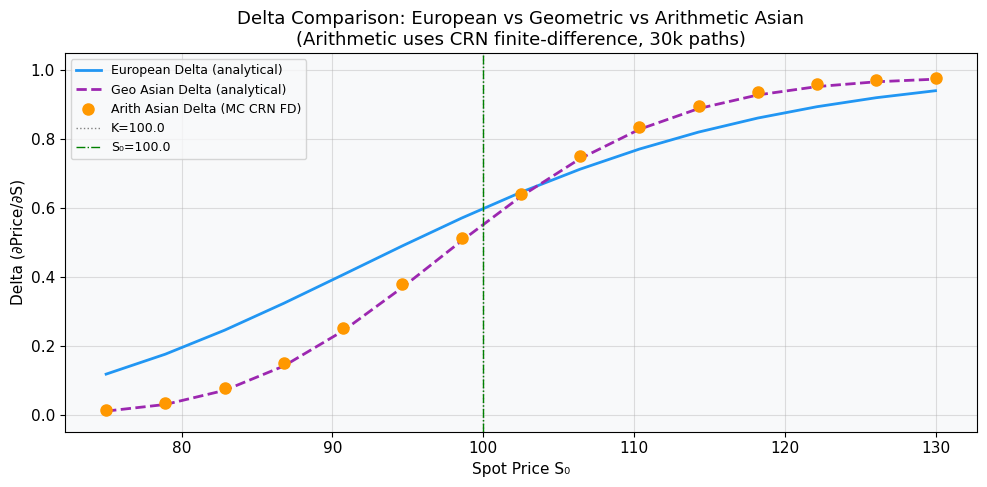


Key observations:
  • All three Deltas have the same S-shape, but Asian options have lower Delta
  • Lower Delta means a smaller hedge ratio: fewer shares needed to delta-hedge
  • The arithmetic Asian Delta ≈ geometric Asian Delta (confirmed numerically)
  • ATM arithmetic Asian Delta < ATM European Delta — averaging dampens sensitivity


In [6]:
# Delta sweep across spot for arithmetic Asian (MC CRN)
# This is slower due to MC; we use a coarser grid
S_coarse  = np.linspace(75, 130, 15)
n_paths_d = 30_000

print("Estimating arithmetic Asian delta across spot prices (CRN finite-difference)...")
arith_deltas = []
eu_deltas_c  = []
geo_deltas_c = []
for S in S_coarse:
    d_arith = asian_delta(S, mp.K, mp.r, mp.sigma, mp.T, mp.N,
                           n_paths=n_paths_d, seed=42)
    d_eu    = bs_delta(S, mp.K, mp.r, mp.sigma, mp.T, 'call')
    d_geo   = geo_asian_greeks(S, mp.K, mp.r, mp.sigma, mp.T, mp.N)['delta']
    arith_deltas.append(d_arith)
    eu_deltas_c.append(d_eu)
    geo_deltas_c.append(d_geo)

arith_deltas = np.array(arith_deltas)
eu_deltas_c  = np.array(eu_deltas_c)
geo_deltas_c = np.array(geo_deltas_c)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S_coarse, eu_deltas_c,  color='#2196F3', lw=2,   label='European Delta (analytical)')
ax.plot(S_coarse, geo_deltas_c, color='#9C27B0', lw=2, ls='--', label='Geo Asian Delta (analytical)')
ax.plot(S_coarse, arith_deltas, 'o', color='#FF9800', ms=8, label='Arith Asian Delta (MC CRN FD)')
ax.axvline(mp.K,  color='grey',  lw=1, ls=':',  label=f'K={mp.K}')
ax.axvline(mp.S0, color='green', lw=1, ls='-.', label=f'S₀={mp.S0}')
ax.set_xlabel('Spot Price S₀')
ax.set_ylabel('Delta (∂Price/∂S)')
ax.set_title('Delta Comparison: European vs Geometric vs Arithmetic Asian\n'
             '(Arithmetic uses CRN finite-difference, 30k paths)')
ax.legend(fontsize=9)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("  • All three Deltas have the same S-shape, but Asian options have lower Delta")
print("  • Lower Delta means a smaller hedge ratio: fewer shares needed to delta-hedge")
print("  • The arithmetic Asian Delta ≈ geometric Asian Delta (confirmed numerically)")
print("  • ATM arithmetic Asian Delta < ATM European Delta — averaging dampens sensitivity")

## 7. Volatility Sensitivity (Vega) Comparison

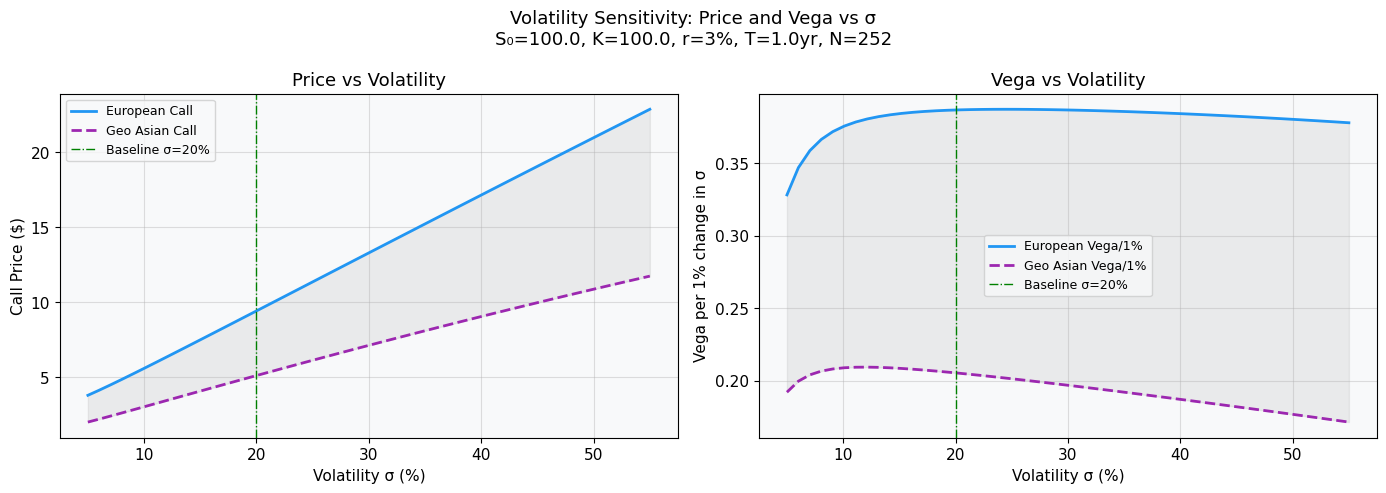

At baseline σ=20%:
  European  price = $9.4134,  vega/1% = $0.3867
  Geo Asian price = $5.1031,  vega/1% = $0.2055
  Asian Vega is 0.532× that of European — lower vol sensitivity due to averaging


In [7]:
sigma_sweep = np.linspace(0.05, 0.55, 50)

eu_prices_s   = [bs_call_price(mp.S0, mp.K, mp.r, s, mp.T)                   for s in sigma_sweep]
geo_prices_s  = [geometric_asian_call(mp.S0, mp.K, mp.r, s, mp.T, mp.N)      for s in sigma_sweep]
eu_vegas_s    = [bs_vega(mp.S0, mp.K, mp.r, s, mp.T, per_percent=True)       for s in sigma_sweep]
geo_vegas_s   = [geo_asian_greeks(mp.S0, mp.K, mp.r, s, mp.T, mp.N)['vega']  for s in sigma_sweep]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Volatility Sensitivity: Price and Vega vs σ\n'
             f'S₀={mp.S0}, K={mp.K}, r={mp.r:.0%}, T={mp.T}yr, N={mp.N}', fontsize=13)

axes[0].plot(sigma_sweep * 100, eu_prices_s,  color='#2196F3', lw=2, label='European Call')
axes[0].plot(sigma_sweep * 100, geo_prices_s, color='#9C27B0', lw=2, ls='--', label='Geo Asian Call')
axes[0].axvline(mp.sigma * 100, color='green', lw=1, ls='-.', label=f'Baseline σ={mp.sigma:.0%}')
axes[0].fill_between(sigma_sweep * 100, geo_prices_s, eu_prices_s, alpha=0.12, color='grey')
axes[0].set_xlabel('Volatility σ (%)')
axes[0].set_ylabel('Call Price ($)')
axes[0].set_title('Price vs Volatility')
axes[0].legend(fontsize=9)

axes[1].plot(sigma_sweep * 100, eu_vegas_s,  color='#2196F3', lw=2, label='European Vega/1%')
axes[1].plot(sigma_sweep * 100, geo_vegas_s, color='#9C27B0', lw=2, ls='--', label='Geo Asian Vega/1%')
axes[1].axvline(mp.sigma * 100, color='green', lw=1, ls='-.', label=f'Baseline σ={mp.sigma:.0%}')
axes[1].fill_between(sigma_sweep * 100, geo_vegas_s, eu_vegas_s, alpha=0.12, color='grey')
axes[1].set_xlabel('Volatility σ (%)')
axes[1].set_ylabel('Vega per 1% change in σ')
axes[1].set_title('Vega vs Volatility')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

eu_at_baseline  = bs_call_price(mp.S0, mp.K, mp.r, mp.sigma, mp.T)
geo_at_baseline = geometric_asian_call(mp.S0, mp.K, mp.r, mp.sigma, mp.T, mp.N)
eu_vega_bl  = bs_vega(mp.S0, mp.K, mp.r, mp.sigma, mp.T, per_percent=True)
geo_vega_bl = geo_asian_greeks(mp.S0, mp.K, mp.r, mp.sigma, mp.T, mp.N)['vega']
print(f"At baseline σ={mp.sigma:.0%}:")
print(f"  European  price = ${eu_at_baseline:.4f},  vega/1% = ${eu_vega_bl:.4f}")
print(f"  Geo Asian price = ${geo_at_baseline:.4f},  vega/1% = ${geo_vega_bl:.4f}")
print(f"  Asian Vega is {geo_vega_bl/eu_vega_bl:.3f}× that of European — lower vol sensitivity due to averaging")